In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

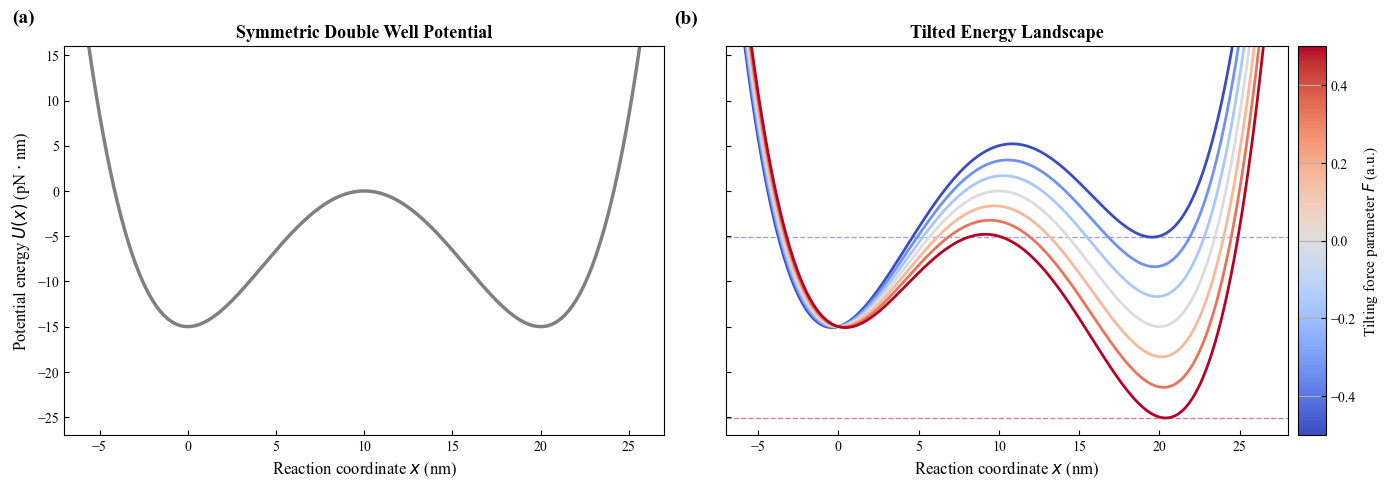

In [3]:
plt.rcParams.update({
    "text.usetex": False,          
    "font.family": "serif",       
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "axes.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

x_drag = 10  
dG_drag = 15  

def potential_0(x):
    return 4 * dG_drag * (0.25 * ((x - x_drag) / x_drag)**4 - 0.5 * ((x - x_drag) / x_drag)**2)

def potential(x, F):
    return potential_0(x) - F * x

x_values = np.linspace(-10, 30, 400)
forces = np.linspace(-0.5, 0.5, 7) 

cmap = plt.cm.coolwarm
norm = mpl.colors.Normalize(vmin=forces.min(), vmax=forces.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# -------- Panel 1: Symmetric --------
axes[0].plot(x_values, potential_0(x_values), color="grey", lw=2.5, label="No force")
axes[0].set_title("Symmetric Double Well Potential", fontsize=13, fontweight='bold')
axes[0].set_xlabel(r"Reaction coordinate $x$ (nm)")
axes[0].set_ylabel(r"Potential energy $U(x)$ (pN $\cdot$ nm)")
axes[0].set_ylim(-27, 16)
axes[0].set_xlim(-7, 27)
axes[0].grid(False) 
axes[0].text(-0.05, 1.05, '(a)', transform=axes[0].transAxes, fontsize=14, fontweight='bold', va='bottom', ha='right')

# -------- Panel 2: Tilted --------
for F in forces:
    y_tilted = potential(x_values, F)
    axes[1].plot(x_values, y_tilted, color=cmap(norm(F)), lw=2)

    if F == forces[0] or F == forces[-1]:
        min_y = np.min(y_tilted[x_values > 15]) 
        axes[1].axhline(min_y, color=cmap(norm(F)), linestyle='--', alpha=0.5, lw=1)

axes[1].set_title("Tilted Energy Landscape", fontsize=13, fontweight='bold')
axes[1].set_xlabel(r"Reaction coordinate $x$ (nm)")
axes[1].set_ylim(-27, 16)
axes[1].set_xlim(-7, 28)
axes[1].grid(False)
axes[1].text(-0.05, 1.05, '(b)', transform=axes[1].transAxes, fontsize=14, fontweight='bold', va='bottom', ha='right')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r"Tilting force parameter $F$ (a.u.)", fontsize=11)
plt.tight_layout()
plt.grid(True)

plt.savefig('energy_landscape_vettoriale.pdf', format='pdf', bbox_inches='tight')
plt.show()



Preparazione animazione...
Salvataggio in corso... attendi qualche secondo.
Fatto! Trovi il file 'landscape_evolution.gif' nella cartella del tuo script.


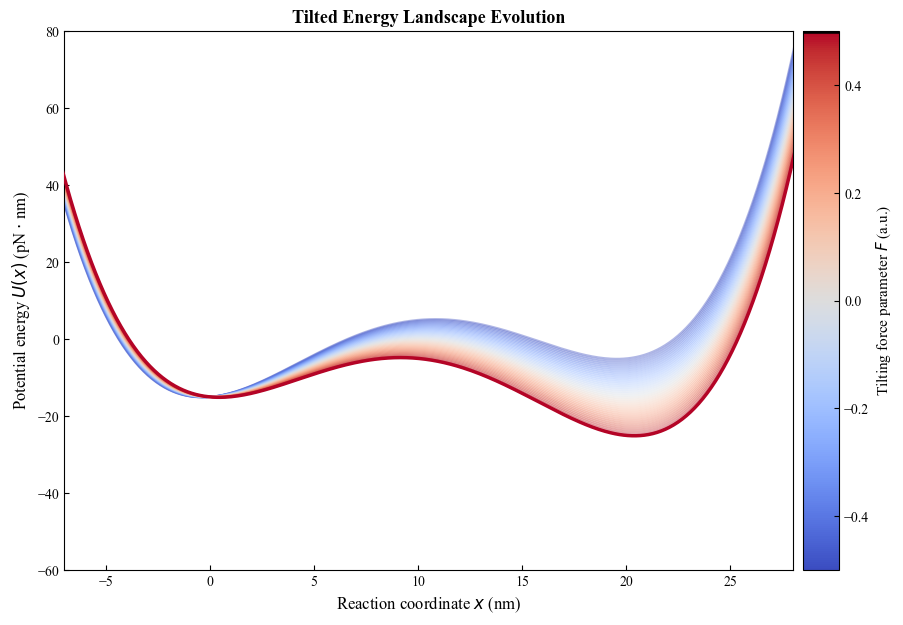

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.animation import FuncAnimation

# Configurazione stile (mantenuta dalla tua originale)
plt.rcParams.update({
    "text.usetex": False,          
    "font.family": "serif",       
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "axes.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

x_drag = 10  
dG_drag = 15  

def potential_0(x):
    return 4 * dG_drag * (0.25 * ((x - x_drag) / x_drag)**4 - 0.5 * ((x - x_drag) / x_drag)**2)

def potential(x, F):
    return potential_0(x) - F * x

# Valori x e forze (coordinate con il tuo grafico originale)
x_values = np.linspace(-10, 30, 400)
forces = np.linspace(- 0.5, 0.5, 40) # 30 passi per una buona fluidità

cmap = plt.cm.coolwarm
norm = mpl.colors.Normalize(vmin=forces.min(), vmax=forces.max())

fig, ax = plt.subplots(figsize=(10, 7))

# Setup grafico statico
ax.set_title("Tilted Energy Landscape Evolution", fontsize=13, fontweight='bold')
ax.set_xlabel(r"Reaction coordinate $x$ (nm)")
ax.set_ylabel(r"Potential energy $U(x)$ (pN $\cdot$ nm)")
ax.set_ylim(-60, 80) # Range adattato al tuo PDF
ax.set_xlim(-7, 28)

# Colorbar con indicatore
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r"Tilting force parameter $F$ (a.u.)", fontsize=11)

# Linee e cursore
lines = []
for F in forces:
    line, = ax.plot([], [], color=cmap(norm(F)), lw=1.5, alpha=0.3)
    lines.append(line)

current_line, = ax.plot([], [], color='black', lw=2.5, zorder=10)
cursor = cax.axhline(forces[0], color='black', lw=4, xmin=-0.5, xmax=1.5, zorder=20)

def init():
    for line in lines:
        line.set_data([], [])
    current_line.set_data([], [])
    cursor.set_ydata([forces[0]])
    return lines + [current_line, cursor]

def update(frame):
    F = forces[frame]
    y_tilted = potential(x_values, F)
    
    # Rendi visibile la curva corrispondente
    lines[frame].set_data(x_values, y_tilted)
    lines[frame].set_alpha(0.4)
    
    # Evidenzia la curva attuale
    current_line.set_data(x_values, y_tilted)
    current_line.set_color(cmap(norm(F)))
    
    # Muovi l'indicatore sulla colorbar
    cursor.set_ydata([F])
    
    return lines + [current_line, cursor]

# Creazione dell'oggetto animazione
print("Preparazione animazione...")
ani = FuncAnimation(fig, update, frames=len(forces), init_func=init, blit=False, repeat=True)

# SALVATAGGIO IN GIF (Pillow non supporta .mp4, quindi usiamo .gif)
# Questo formato non richiede ffmpeg e funzionerà sicuramente.
print("Salvataggio in corso... attendi qualche secondo.")
ani.save('landscape_evolution.gif', writer='pillow', fps=10)

print("Fatto! Trovi il file 'landscape_evolution.gif' nella cartella del tuo script.")
plt.show()

In [ ]:
# LANGEVIN : deterministic + thermal noise 
D  = 3000 # nm**2/s 
kT = 4.11 # pN* nm
dt =  10**(-5)
x0 = 0                  # thats y we shifted (also for tilting)
N_steps= 1_000_000


Mean ⟨x⟩: 161.08246664268935
Mean ⟨x²⟩: 37649.74949539441
Expected ⟨x²⟩ (2Dt): 60000.0
Error in ⟨x²⟩: 0.3725041750767598


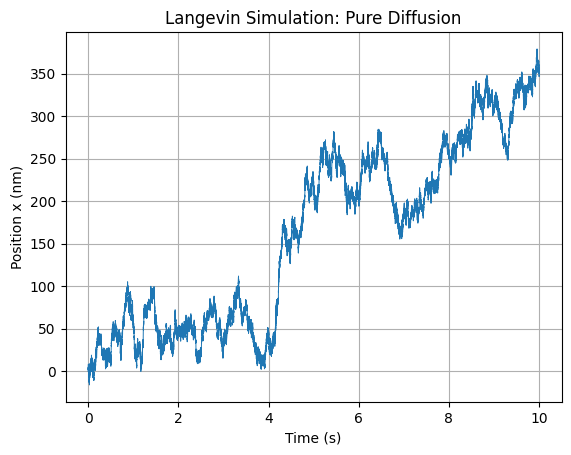

In [5]:
#  PURE DIFFUSION LANGEVIN  F = dudx =  0 with 2 forloops
# check point <x> = 0 ; <x2> = 2Dt 

x = np.zeros(N_steps)
x[0] = 0
for i in range(1, N_steps):
    x[i] = x[i-1] + np.sqrt(2 * D * dt) *np.random.normal(0,1)

time_values = np.arange(N_steps) * dt
expected_x2 = 2 * D * (N_steps * dt)
mean_x2 =  np.mean(( x -  x[0])**2)
print("Mean ⟨x⟩:", np.mean(x))
print("Mean ⟨x²⟩:", mean_x2)
print("Expected ⟨x²⟩ (2Dt):", expected_x2)
print("Error in ⟨x²⟩:", abs((np.mean(mean_x2) - expected_x2)/ expected_x2))

plt.plot(time_values, x, lw=0.7, label="Langevin Trajectory")
plt.xlabel("Time (s)")
plt.ylabel("Position x (nm)")
plt.title("Langevin Simulation: Pure Diffusion")
plt.grid()
plt.show()

## how to interprete +30 in x?? 

In [ ]:
# for loops langevin 
## D/kbT = viscosity
# du0dx = potential gradient 

'''
D, dG_drag, F = 3000, 15, 0.25
dt = 5*10**(-6) 
N_steps =  300_000_000
t_values = np.arange(N_steps) * dt

step = np.linspace(-10, 30, N_steps-1)
x =  np.zeros(N_steps)
x[0]=0
for i in range(1, N_steps):
    du0dx = 4 * dG_drag*  ((1/x_drag)*((x[i-1] - x_drag)/ x_drag)**3 - (1/x_drag)*((x[i-1] - x_drag)/ x_drag))
    dudx = du0dx - F
    x[i] = x[i-1] - (D/kT) * dudx * dt  + np.sqrt(2 * D * dt) * np.random.normal(0, 1)

# plt.figure(figsize=(11, 5))
# plt.plot(t_values, x, lw=0.7, label = f"D: {D}, dG: {dG_drag}, F: {F}")
# plt.xlabel("Time")
# plt.ylabel("Position x")
# plt.title("Langevin Simulation")
# plt.grid()
# plt.legend()
# plt.show()

# partial sampling 
### save only every 100th point
n = np.arange(0, N_steps, 100)
t_values = n * dt
x_values = x[n]
data = np.column_stack((t_values, x_values))
filename = f"langevinSimulation_F{F}.npz" 
if os.path.exists(filename):
    loaded = np.load(filename)
    old_data = loaded["data"]
    data = np.vstack((old_data, data))  # appendo in verticale

# Salvo tutto (sovrascrivendo il file)
np.savez_compressed(filename, header="Time, Position_x", data=data)

'''

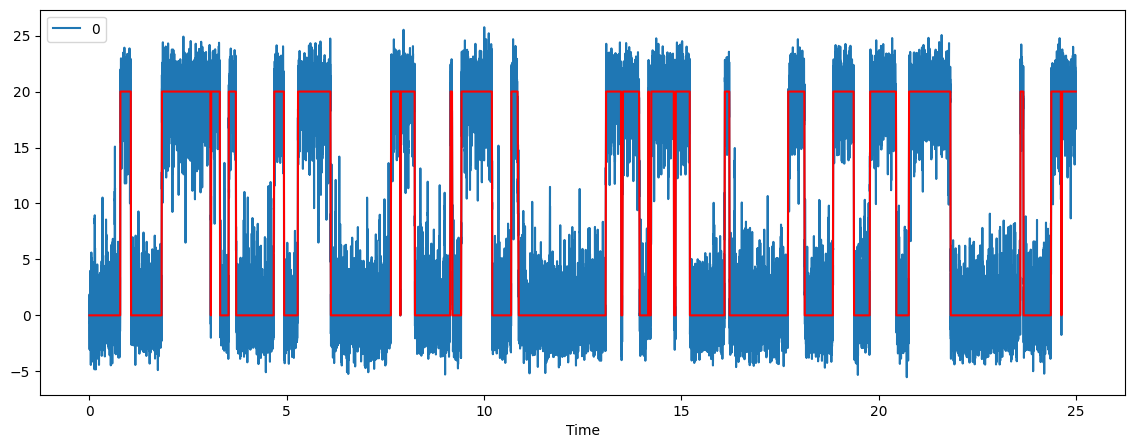

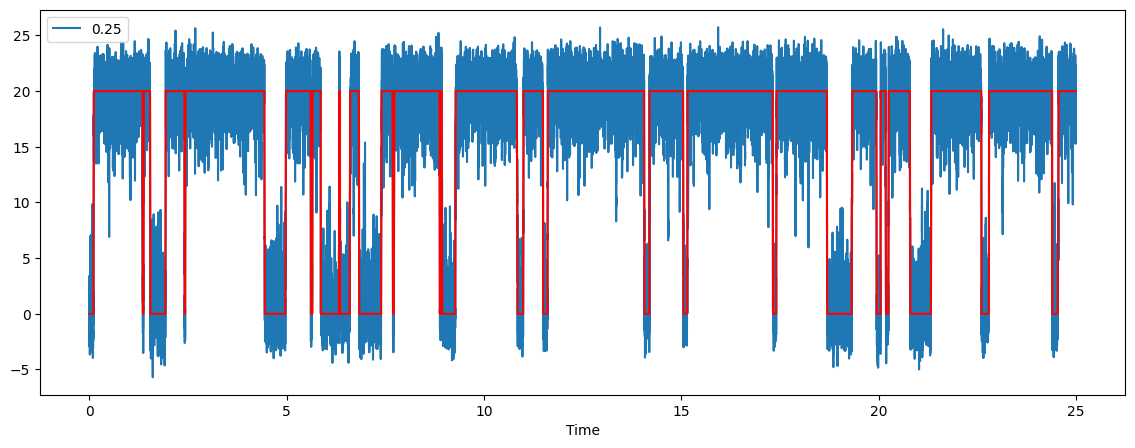

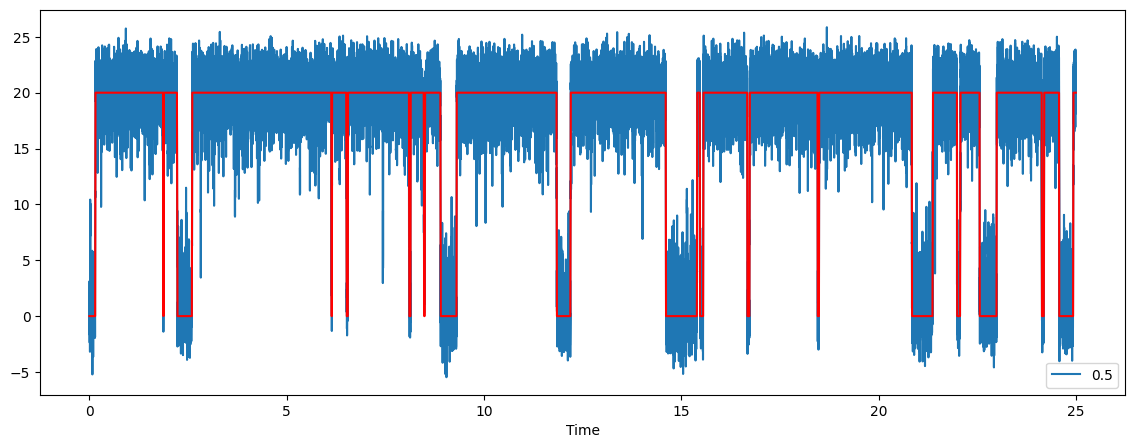

In [4]:
# # #loading back 
for F in (0, 0.25, 0.5): 
    filename = f"langevinSimulation_F{F}.npz"
    loaded = np.load(filename)
    my_array = loaded["data"]
    df = pd.DataFrame(my_array, columns=["Time", "Position_x"])
    
    x = df["Position_x"].values
    t = df["Time"].values
    mask = np.full_like(x, np.nan)
    mask[x < 2] = 0       # folded
    mask[x > 18] = 20  

    valid = ~np.isnan(mask[:50000])
    plt.figure(figsize=(14, 5))
    ax = plt.gca() 
    df.iloc[:50000, :50000].plot(x=df.columns[0], y=df.columns[1], ax=ax, label= f'{F}')
    plt.plot(t[:50000][valid], mask[:50000][valid], label="State mask (0/20)", 
             color='red', linewidth=1.5)   
    plt.show()

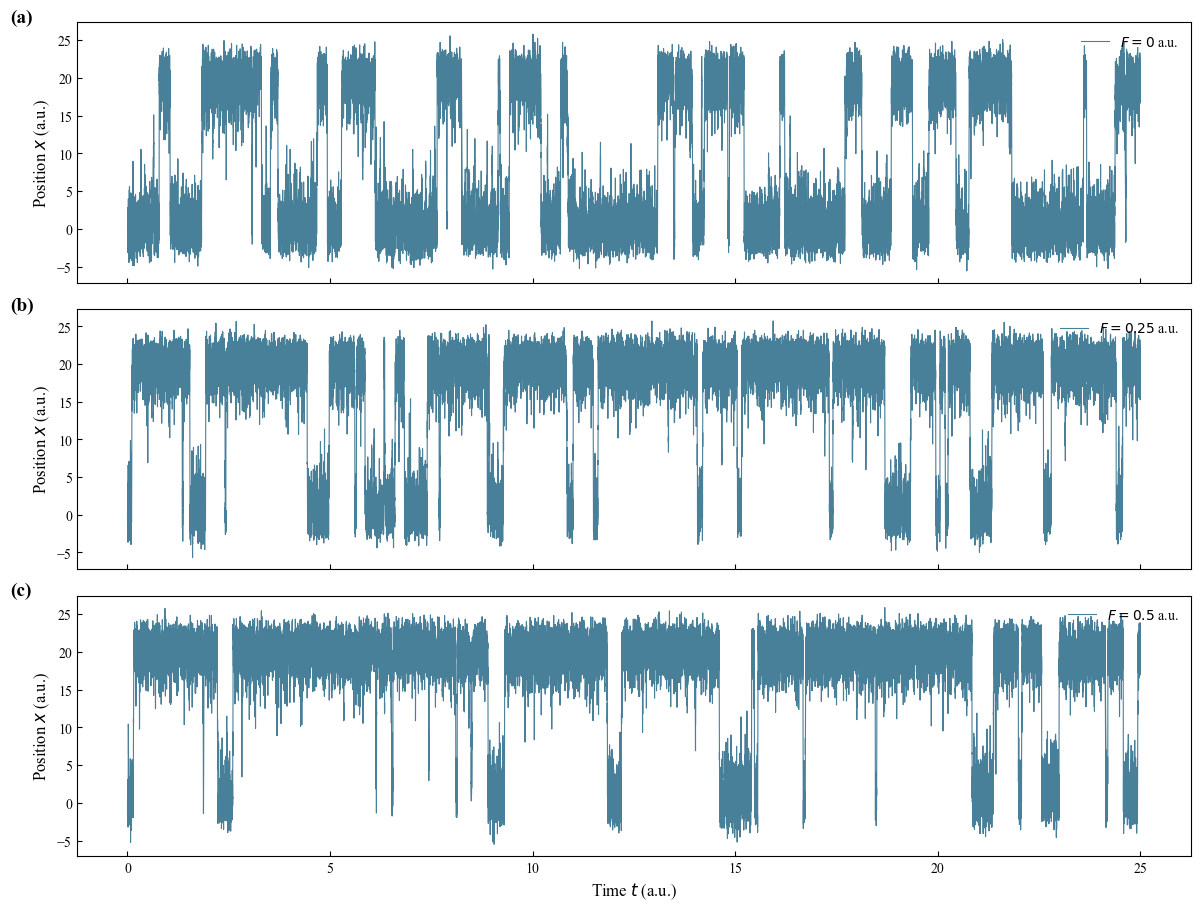

In [72]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "grid.alpha": 0.3
})

forces = [0, 0.25, 0.5]
colors = ["#1C6080", "#1C6080", "#1C6080"]
fig, axes = plt.subplots(len(forces), 1, figsize=(12, 10), sharex=True)

for i, F in enumerate(forces):
    try:
        filename = f"langevinSimulation_F{F}.npz"
        loaded = np.load(filename)
        my_array = loaded["data"]
        
        t = my_array[:50000, 0]
        x = my_array[:50000, 1]
        
        axes[i].plot(t, x, color=colors[i], lw=0.8, alpha=0.8, label=f"$F = {F}$ a.u.")
        
        axes[i].set_ylabel(r"Position $x$ (a.u.)")
        axes[i].legend(loc="upper right", frameon=False, fontsize=10)
        axes[i].grid(False) 
        
        label = f"({chr(97+i)})"
        axes[i].text(-0.06, 1.05, label, transform=axes[i].transAxes, 
                     fontsize=14, fontweight='bold', va='top')

    except FileNotFoundError:
        print(f"File {filename} non trovato.")

axes[-1].set_xlabel(r"Time $t$ (a.u.)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 

plt.savefig('trajectories_combined.pdf', format='pdf', bbox_inches='tight')
plt.show()

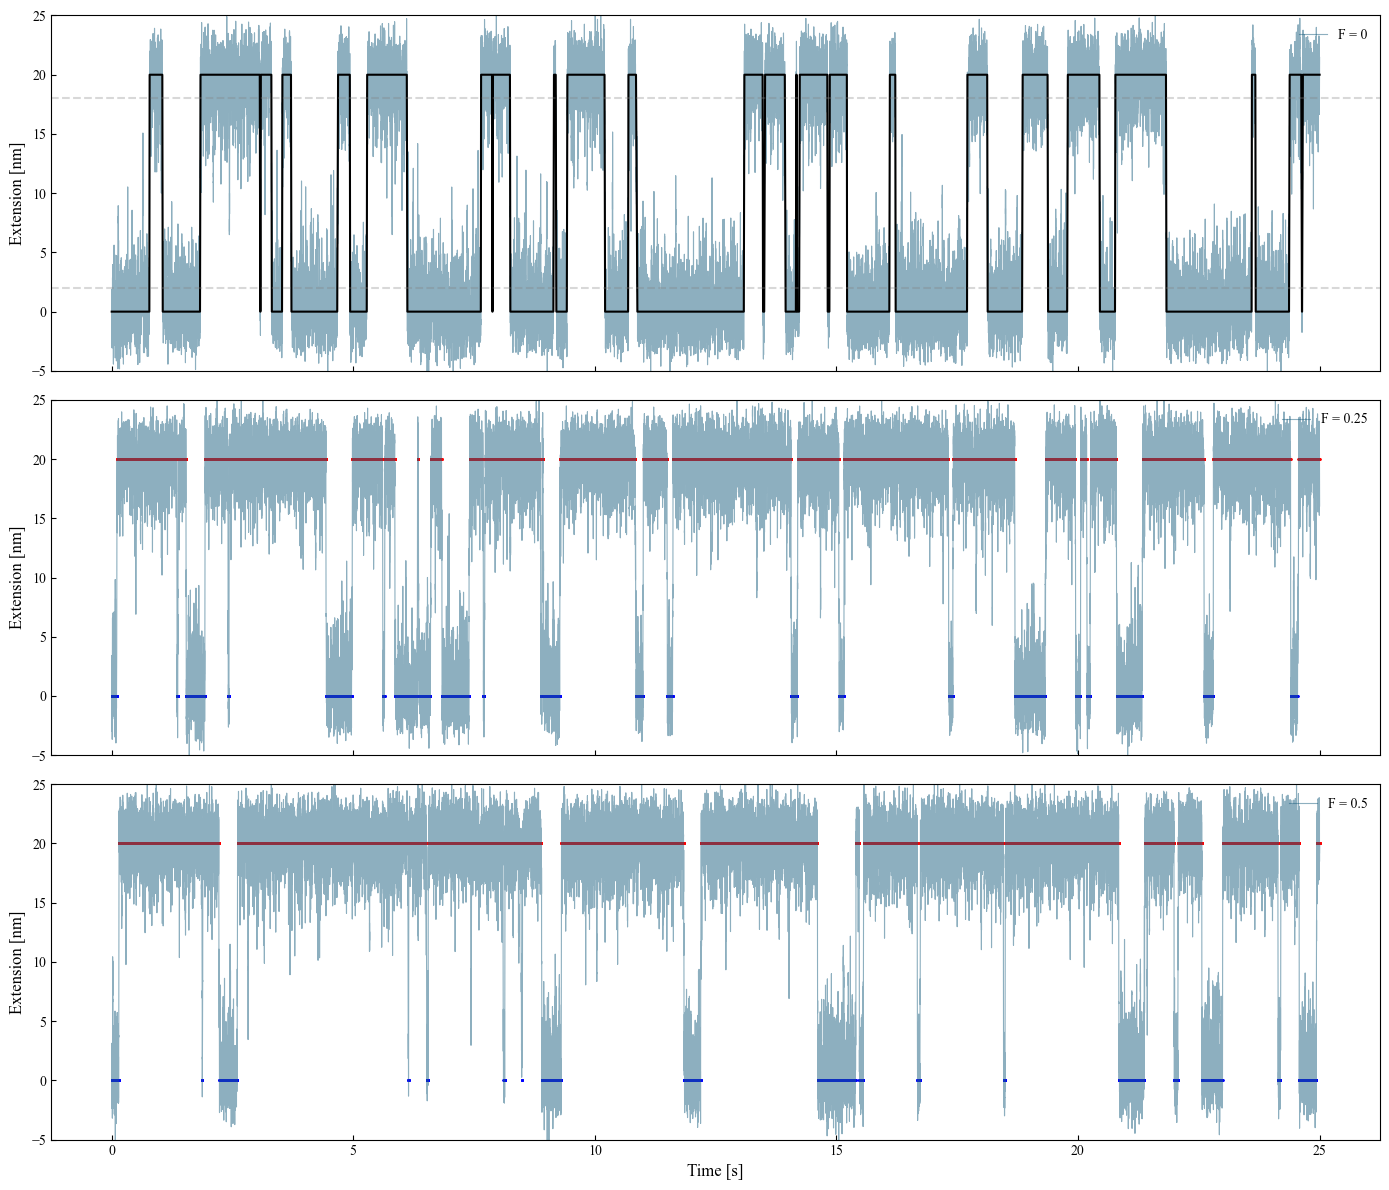

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

F_list = [0, 0.25, 0.5]
traj_color = "#1C6080"
mask_color = "black"
f_color = "blue"
u_color = "red"
low_th = 2
up_th = 18
pts = 50000

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for i, F in enumerate(F_list):
    filename = f"langevinSimulation_F{F}.npz"
    loaded = np.load(filename)
    data = loaded["data"]
    t = data[:pts, 0]
    x = data[:pts, 1]
    
    axes[i].plot(t, x, color=traj_color, alpha=0.5, linewidth=0.8, label=f'F = {F}')
    
    m = np.full_like(x, np.nan)
    m[x < low_th] = 0
    m[x > up_th] = 20
    
    if i == 0:
        valid = ~np.isnan(m)
        axes[i].plot(t[valid], m[valid], color=mask_color, linewidth=1.5)
        axes[i].axhline(2, color='gray', linestyle='--', alpha=0.3)
        axes[i].axhline(18, color='gray', linestyle='--', alpha=0.3)
    else:
        m_f = np.where(x < low_th, 0, np.nan)
        m_u = np.where(x > up_th, 20, np.nan)
        axes[i].scatter(t, m_f, color=f_color, s=1)
        axes[i].scatter(t, m_u, color=u_color, s=1)

    
    axes[i].set_ylim(-5, 25)
    axes[i].set_ylabel("Extension [nm]")
    axes[i].legend(loc='upper right', frameon=False)

axes[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.savefig('mask_dwelltime.pdf', format='pdf', bbox_inches='tight')

plt.show()

In [97]:
## SAVING TIME LIST 
up_threshold = 18
low_threshold = 2
result_style = []
F_list = [-0.5, -0.25, 0, 0.25, 0.5]

filename = f'langevinSimulation_F{F}.npz'


def process_file(filename):
## fortran file 
    # data = np.loadtxt(filename)
## uncomment for npz python file
    loaded = np.load(filename)   
    data = loaded["data"]
    t = data[:, 0]
    x = data[:, 1]

    # STEP 1: Mappatura in stati binari: 0 (folded), 20 (unfolded), NaN altrove
    state = np.full_like(x, np.nan)
    state[x < low_threshold] = 0       # folded
    state[x > up_threshold] = 20       # unfolded

    # STEP 2: Rimuovi i punti ambigui (NaN → zona intermedia)
    valid_indices = ~np.isnan(state)
    state = state[valid_indices]
    t = t[valid_indices]

    # STEP 3: Loop per identificare transizioni e calcolare dwell times
    t_fold = []     # da unfolded (20) → folded (0)
    t_unfold = []   # da folded (0) → unfolded (20)

    last_state = state[0]
    last_time = t[0]

    for i in range(1, len(state)):
        if state[i] != last_state:
            dt = t[i] - last_time

            if last_state == 20 and state[i] == 0:
                t_unfold.append(dt)
            elif last_state == 0 and state[i] == 20:
                t_fold.append(dt)

            last_state = state[i]
            last_time = t[i]

    # Ultimo segmento (facoltativo)
    dt = t[-1] - last_time
    if last_state == 20:
        t_unfold.append(dt)
    elif last_state == 0:
        t_fold.append(dt)

    # STEP 4: Calcolo dei rate
    min_dwell = 0.0 # filtro contro rumore
    t_fold = [dt for dt in t_fold if dt >= min_dwell]
    t_unfold = [dt for dt in t_unfold if dt >= min_dwell]

    folding_rate = 1 / np.mean(t_unfold) if t_fold else 0
    unfolding_rate = 1 / np.mean(t_fold) if t_unfold else 0


    return F, folding_rate, unfolding_rate, t_unfold, t_fold 

# # PYTHON DATA 
results = []
for F in F_list:
    F, folding_rate, unfolding_rate, t_up_list, t_down_list = process_file(f'langevinSimulation_F{F}.npz')
    
    results.append({
        "F": F,
        "folding_rate": folding_rate,
        "unfolding_rate": unfolding_rate,
        "t_up_list": t_up_list,
        "t_down_list": t_down_list
    })

df = pd.DataFrame(results)
df

### FORTRAN DATA
# results = []
# for F in (-2, -1.5, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 1.5, 2):
#     F, folding_rate, unfolding_rate, t_up_list, t_down_list = process_file(f'trajectoryF{F}')

#     results.append({
#         "F": F,
#         "folding_rate": folding_rate,
#         "unfolding_rate": unfolding_rate,
#         "t_up_list": t_up_list,
#         "t_down_list": t_down_list
#     })

# df_fortran = pd.DataFrame(results)
# df_fortran.to_pickle("dati_fortran.pkl")


,F,folding_rate,unfolding_rate,t_up_list,t_down_list
0,-0.50,6.023502,0.642910,"[0.045500000000000096, 0.24049999999999994, 0....","[1.7839999999999998, 3.8139999999999996, 6.701..."
1,-0.25,3.941281,1.244025,"[0.14, 0.27249999999999996, 0.377, 0.109999999...","[0.7599999999999999, 0.13749999999999996, 0.06..."
2,0.00,2.256887,2.281420,"[0.27149999999999996, 1.2369999999999999, 0.22...","[0.7835, 0.7814999999999999, 0.012999999999999..."
3,0.25,1.228953,3.814343,"[1.2414999999999998, 0.16549999999999998, 0.47...","[0.11299999999999999, 0.023500000000000076, 0...."
4,0.50,0.659841,6.178414,"[1.7229999999999999, 0.345, 3.533, 0.371999999...","[0.1515, 0.010999999999999899, 0.3745000000000..."


In [79]:
from scipy.optimize import minimize_scalar
from scipy.integrate import quad


# KRAMER PARAMS 
D, kT =  3000, 4.11 # nm2/s
dG_drag = 15 #pN nm (= 3kT)
A, B = 1/4, 1/2
k = 4.11
F_list = [-2, -1.5, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 1.5, 2]


def U (x):
    z = (x - x_drag) / x_drag
    return 4 * dG_drag * (A * z**4 - B * z**2) - F * x

def dU (x):
    z = (x - x_drag) / x_drag
    return 4 * dG_drag * (1 / x_drag) * (4 * A * z**3 - 2 * B * z) - F

def d2U (x):
    z = (x - x_drag) / x_drag
    return 4 * dG_drag * (1 / x_drag**2) * (12 * A * z**2 - 2 * B)

# kramer for reaction rate transition 
def kramer(D, dG, w_a, w_b, kT):
   return (w_a *  w_b * D) / (2 * np.pi * kT) * np.exp(- dG/ kT)  

kramer_result = [] 

for F in F_list:
    res1 = minimize_scalar(U, bounds=(-1, +1), method='bounded') #minimo sx
    x_folded = res1.x
    res2 = minimize_scalar(U, bounds=(19, 21), method='bounded') #minimo dx
    x_unfolded = res2.x
    res_barrier = minimize_scalar(lambda x: -U(x), bounds=(9.5, 10.5), method='bounded') #max
    x_top = res_barrier.x

    dG_fold = U(x_top) - U(x_unfolded)
    dG_unfold = U(x_top) - U(x_folded) 

    linear_dG = dG_drag - F* x_top  

    # freq calcolata con quanto è ripida la curvatura
    w_a1 = np.sqrt(d2U(x_folded)) #rate per uscire dallo stato di folded 
    w_a2 = np.sqrt(d2U(x_unfolded))
    w_b = np.sqrt(abs(d2U(x_top)))

    k_fold = kramer(D, dG_fold, w_a1, w_b, kT)
    k_unfold = kramer(D, dG_unfold, w_a2, w_b, kT)
#------------------------------------------
    from scipy.integrate import quad

    def mfpt(x, x_a, x_b, U, kT, D):    
    # Inner integral over z from x_a to y
        def inner_integral(y):
            result, _ = quad(lambda z: np.exp(-U(z) / kT), x_a, y)
            return result
    
    # Outer integral over y from x to x_b
        def outer_integral():
            result, _ = quad(lambda y: np.exp(U(y) / kT) * inner_integral(y), x, x_b)
            return result
    
        return outer_integral() / D
    

    mfpt_value = mfpt(x_folded, x_folded - 5 , x_unfolded, U, kT, D)
    rate_unfold = 1 / mfpt_value
    mfpt_value2 = mfpt(x_unfolded, x_unfolded + 5, x_folded, U, kT, D)
    rate_fold = 1 / mfpt_value2


    rate_vs = 1/  mfpt(x_folded, x_folded - 5 , x_top, U, kT, D)



    kramer_result.append([F, dG_fold, dG_unfold, linear_dG, k_fold, k_unfold, x_folded, x_unfolded, x_top, rate_unfold, rate_fold, rate_vs ])


df_k = pd.DataFrame(kramer_result, columns=["F", "dG_fold", "dG_unfold", "linear_dG",  "kramer_fold", "kramer_unfold", "x_f", "x_u", "x_top", "mfpt_r_u", "mfpt_r_f", "rate_vs"])
df_k

,F,dG_fold,dG_unfold,linear_dG,kramer_fold,kramer_unfold,x_f,x_u,x_top,mfpt_r_u,mfpt_r_f,rate_vs
0,-2.00,-2.616420,37.263581,35.999988,212.845761,0.009588,-9.999960e-01,19.000004,10.499994,0.005344,43.138779,0.051238
1,-1.50,1.633585,31.513586,30.749991,75.679198,0.038843,-9.999960e-01,19.000004,10.499994,0.031712,26.638365,0.171317
2,-1.00,5.883982,25.811807,25.499994,26.049379,0.156412,-7.474444e-01,19.030131,10.499994,0.157685,14.124047,0.533401
3,-0.50,10.284007,20.275245,20.249997,8.513434,0.659542,-3.931748e-01,19.553930,10.499994,0.648187,6.180612,1.528029
4,-0.25,12.578737,17.577649,17.604348,4.746486,1.321004,-2.021615e-01,19.784768,10.417393,1.227364,3.793793,2.556645
5,0.00,15.000000,15.000000,15.000000,2.563005,2.563005,-3.898795e-07,20.000000,10.000000,2.212954,2.212954,4.548378
6,0.25,17.577649,12.578737,12.604348,1.321004,4.746486,2.152324e-01,20.202161,9.582607,3.793793,1.227364,7.751436
7,0.50,20.275245,10.284007,10.249997,0.659542,8.513434,4.460698e-01,20.393175,9.500006,6.180612,0.648187,11.562704
8,1.00,25.811807,5.883982,5.499994,0.156412,26.049379,9.698686e-01,20.747444,9.500006,14.124047,0.157685,22.738045
9,1.50,31.513586,1.633585,0.749991,0.038843,75.679204,9.999960e-01,20.999996,9.500006,26.638365,0.031712,39.993720


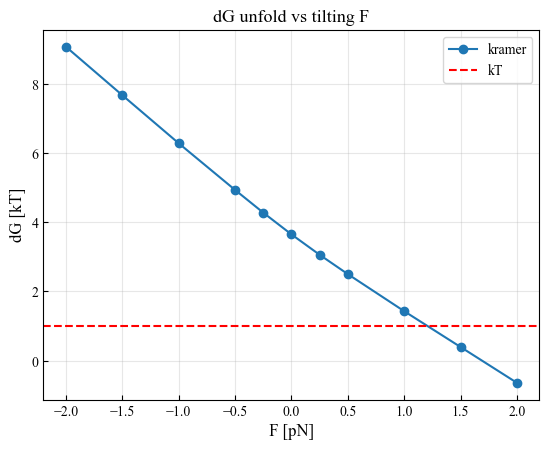

In [80]:
# # dG vs F (unfolding )

plt.plot(df_k["F"], df_k["dG_unfold"]/kT, label = "kramer", marker='o')
plt.axhline(1, label="kT", linestyle = "--", color ="red")

#plt.plot(df_k["F"], df_k["linear_dG"],label = "linear dG")

plt.ylabel("dG [kT]")
plt.xlabel(" F [pN] ")
plt.legend()
plt.title("dG unfold vs tilting F")
plt.grid(True)
plt.show()


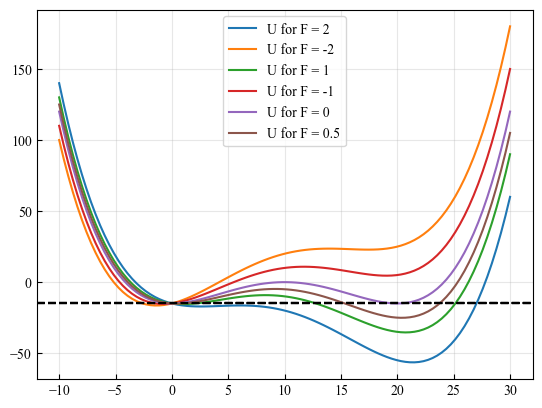

In [81]:
# check if dG is fine 
# F CRITICAL 
F_list = [ 2, -2, 1, -1,  0, 0.5]
x_values = np.linspace(-10, 30, 100)  

for F in F_list:
    potential_values =  potential(x_values, F)
    plt.plot(x_values, potential_values,  label = f"U for F = {F}")
    #
    # plt.ylim(-30,20)
    #plt.xlim(-5, 5)
    plt.legend()
    plt.grid("True")
    plt.axhline( y = - dG_drag, linestyle="--", color = "black")

plt.show()

In [82]:
## compute tau error : rate = 1/<tau> 
## mean tau error :
err_tau_u = np.std(t_up_list)/ np.sqrt(len(t_up_list))
err_tau_f = np.std(t_down_list)/ np.sqrt(len(t_down_list))

err_rate_u = err_tau_f / (np.mean(t_down_list))**2
err_rate_f = err_tau_u / (np.mean(t_up_list))**2

err_log_rate_f = err_rate_f / folding_rate
err_log_rate_u = err_rate_u /unfolding_rate

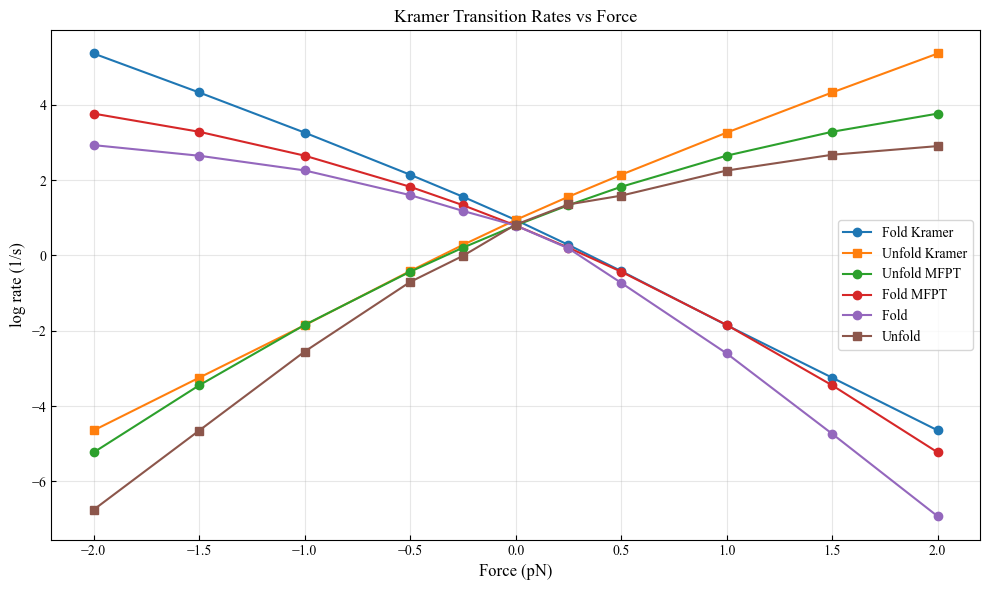

In [118]:
plt.figure(figsize=(10, 6))

# #kramer 

plt.plot(df_k["F"], np.log(df_k["kramer_fold"]), label="Fold Kramer", marker='o')
plt.plot(df_k["F"], np.log(df_k["kramer_unfold"]), label="Unfold Kramer", marker='s')

# # # MFPT 
plt.plot(df_k["F"], np.log(df_k["mfpt_r_u"]), label="Unfold MFPT", marker='o')
#plt.plot(df_k["F"], np.log(df_k["rate_vs"]), label=" MFPT vs", marker='o')  # vs kramer bad approx 
plt.plot(df_k["F"], np.log(df_k["mfpt_r_u"].iloc[::-1].reset_index(drop=True)), label="Fold MFPT", marker='o')

# simulation
plt.plot(df_fortran["F"], np.log(df_fortran["folding_rate"]), label="Fold ", marker='o')
plt.plot(df_fortran["F"], np.log(df_fortran["unfolding_rate"]),  label="Unfold", marker='s')
#plt.errorbar(df["F"], np.log(df["folding_rate"]), yerr = err_log_rate_f, label="Fold ± SEM")
#plt.errorbar(df_fortran["F"], np.log(df_fortran["unfolding_rate"]), yerr = err_log_rate_u, label="Unfold ± SEM")

plt.xlabel("Force (pN)")
plt.ylabel("log rate (1/s)")
plt.title("Kramer Transition Rates vs Force")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# decreasing the barrier (for UNF process) so moving to >>F, kramer'assumpton fails 

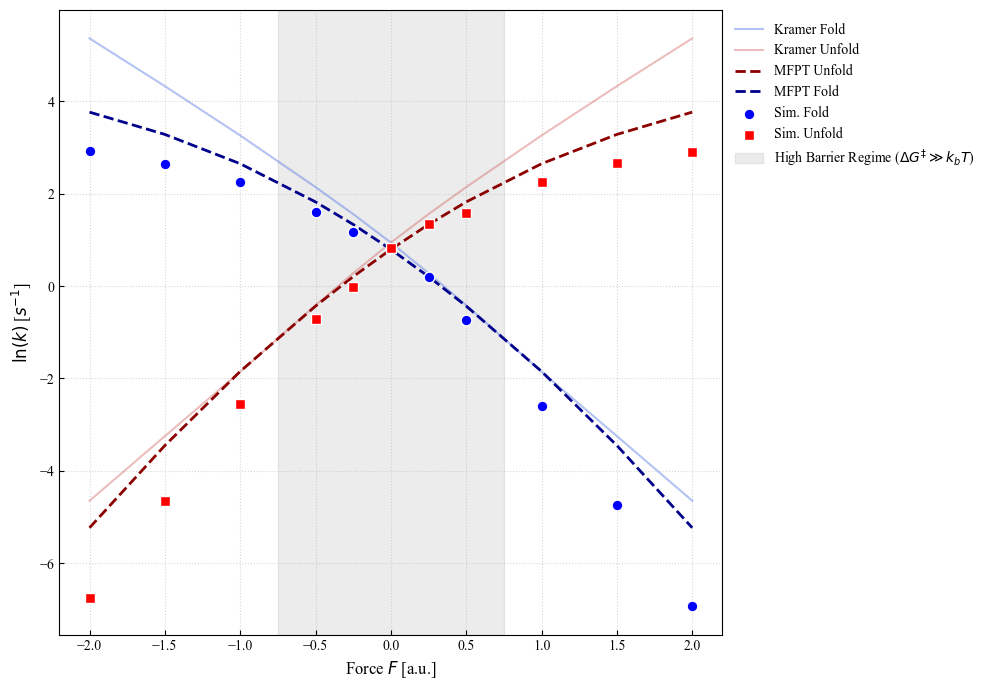

In [138]:
plt.figure(figsize=(10, 7))

# 1. MODELLI ANALITICI (Kramer - validi solo per barriere alte)
plt.plot(df_k["F"], np.log(df_k["kramer_fold"]), label="Kramer Fold", color='royalblue', alpha=0.4, linestyle='-')
plt.plot(df_k["F"], np.log(df_k["kramer_unfold"]), label="Kramer Unfold", color='indianred', alpha=0.4, linestyle='-')

# 2. MODELLI INTEGRALI (MFPT - validi su tutto il range)
plt.plot(df_k["F"], np.log(df_k["mfpt_r_u"]), label="MFPT Unfold", color='darkred', linestyle='--', linewidth=2)
# Genero il Fold MFPT per simmetria rispetto al punto di coesistenza
fold_mfpt = df_k["mfpt_r_u"].iloc[::-1].values 
plt.plot(df_k["F"], np.log(fold_mfpt), label="MFPT Fold", color='darkblue', linestyle='--', linewidth=2)

# 3. DATI SIMULAZIONE (Langevin)
plt.scatter(df_fortran["F"], np.log(df_fortran["folding_rate"]), color='blue', edgecolors='white', s=60, label="Sim. Fold", zorder=5)
plt.scatter(df_fortran["F"], np.log(df_fortran["unfolding_rate"]), color='red', marker='s', edgecolors='white', s=45, label="Sim. Unfold", zorder=5)

# 4. AREA HIGH BARRIER REGIME (Validità Bell/Kramer)
# Definiamo l'area tra -0.5 e 0.5 pN (o il range dove le rette toccano i punti)
plt.axvspan(-0.75, 0.75, color='gray', alpha=0.15, label="High Barrier Regime ($\Delta G ^{\ddagger} \gg k_bT$)")

# Formattazione
plt.xlabel("Force $F$ [a.u.]", fontsize=12)
plt.ylabel(r"$\ln(k)$ [$s^{-1}$]", fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('RATES.pdf', format='pdf', bbox_inches='tight')

plt.show()

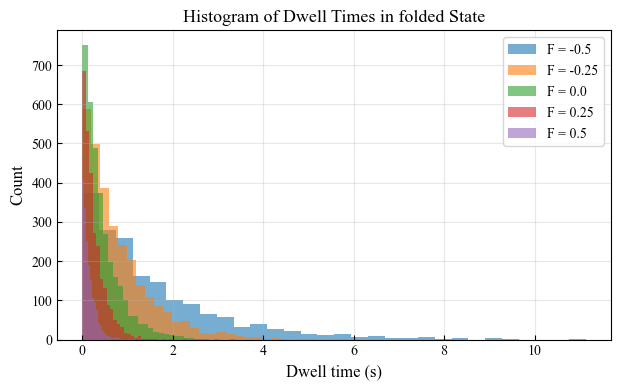

In [99]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 2)
for i, row in df.iterrows():
    t_fold_list = row["t_down_list"]
    F = row["F"]
    plt.hist(t_fold_list, bins=30, alpha=0.6, label=f'F = {F}')  # no color specified

plt.title("Histogram of Dwell Times in folded State")
plt.xlabel("Dwell time (s)")
plt.ylabel("Count")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


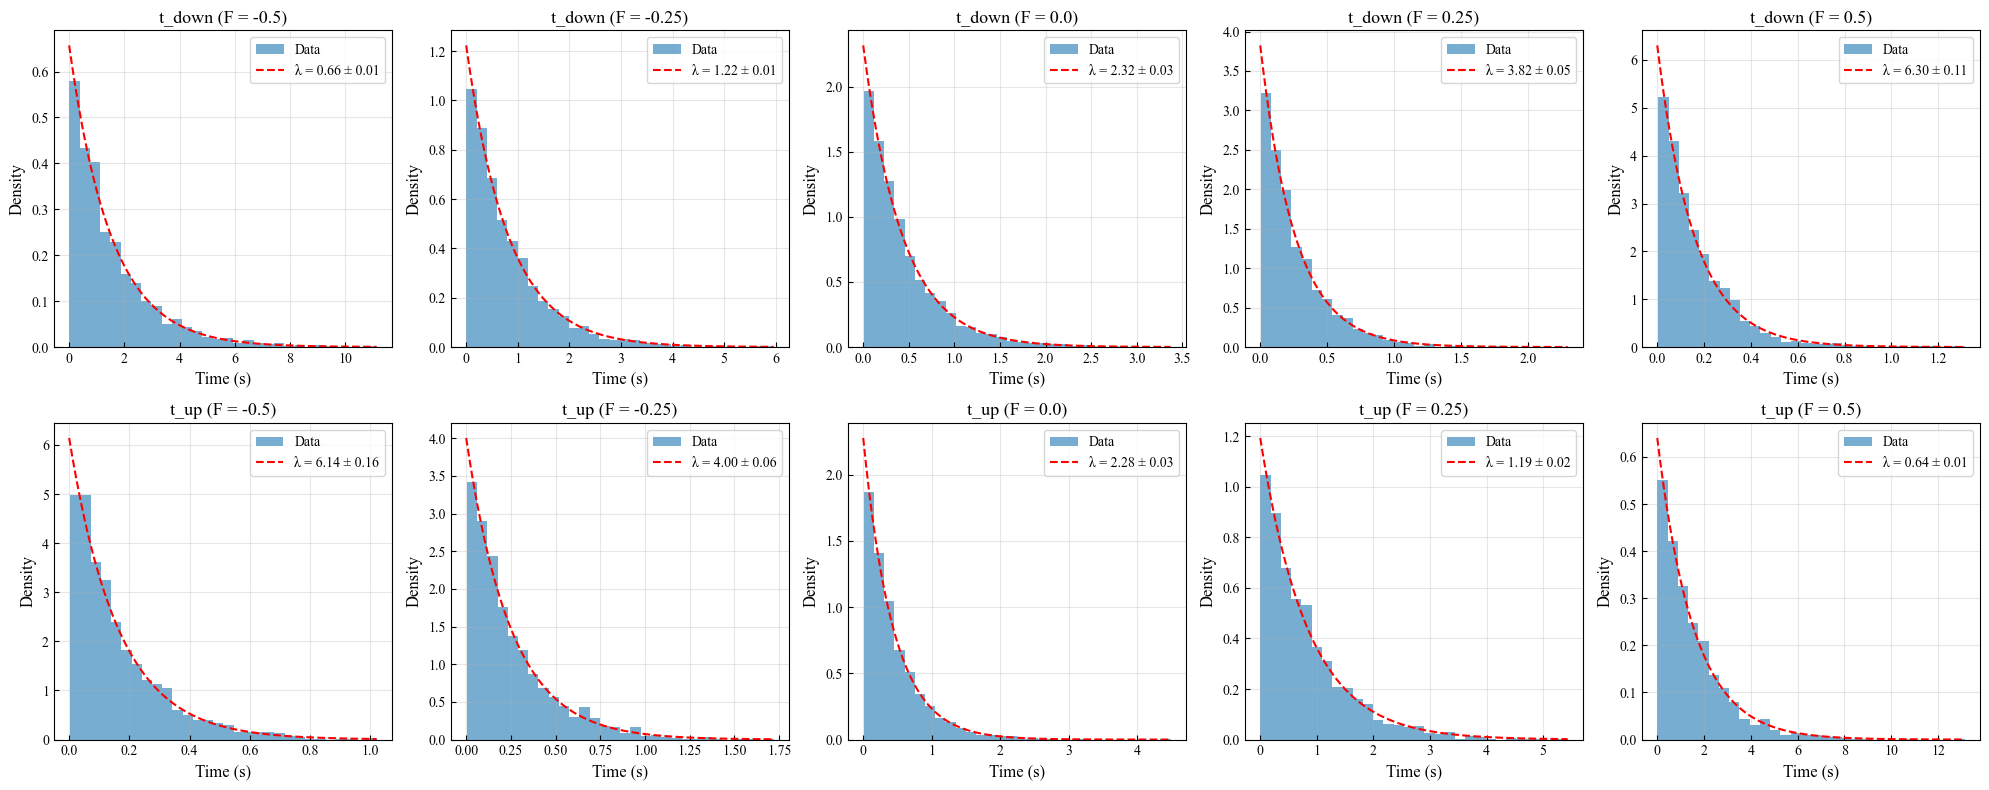

In [100]:
from scipy.optimize import curve_fit

def exp_pdf(t, lambd):
    return lambd * np.exp(-lambd * t)

# Colonne per salvare i fit
for direction in ["up", "down"]:
    df[f"lambda_{direction}"] = np.nan
    df[f"lambda_{direction}_err"] = np.nan

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, row in df.iterrows():
    F = row["F"]

    for j, direction in enumerate(["down", "up"]):
        t_list = np.array(row[f"t_{direction}_list"])
        ax = axes[j, i]

        # Istogramma
        counts, bins, _ = ax.hist(t_list, bins=30, density=True, alpha=0.6, label="Data")
        bin_centers = (bins[:-1] + bins[1:]) / 2

        # Fit
        popt, pcov = curve_fit(exp_pdf, bin_centers, counts, p0=[1 / np.mean(t_list)])
        lam = popt[0]
        lam_std = np.sqrt(pcov[0, 0])

        # Plot fit
        t_fit = np.linspace(0, max(t_list), 300)
        ax.plot(t_fit, exp_pdf(t_fit, lam), 'r--', label=f'λ = {lam:.2f} ± {lam_std:.2f}')

        ax.set_title(f"t_{direction} (F = {F})")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Density")
        ax.grid(True)
        ax.legend()

        # Salva i valori nel DataFrame
        df.at[i, f"lambda_{direction}"] = lam
        df.at[i, f"lambda_{direction}_err"] = lam_std

plt.tight_layout()
plt.show()


In [108]:
df
df_final = df.drop(columns=["t_up_list", "t_down_list"])

df_final

#1/rate =  mean dwell time obv 

,F,folding_rate,unfolding_rate,lambda_up,lambda_up_err,lambda_down,lambda_down_err,kF_folded,kF_folded_err,kF_unfolded,kF_unfolded_err
0,-0.50,6.023502,0.642910,6.141276,0.158305,0.656831,0.012487,NaN,NaN,NaN,NaN
1,-0.25,3.941281,1.244025,4.002850,0.061238,1.222946,0.014872,NaN,NaN,NaN,NaN
2,0.00,2.256887,2.281420,2.276247,0.025734,2.316387,0.026291,NaN,NaN,NaN,NaN
3,0.25,1.228953,3.814343,1.193043,0.019021,3.824308,0.052990,NaN,NaN,NaN,NaN
4,0.50,0.659841,6.178414,0.640408,0.008341,6.304869,0.106075,NaN,NaN,NaN,NaN


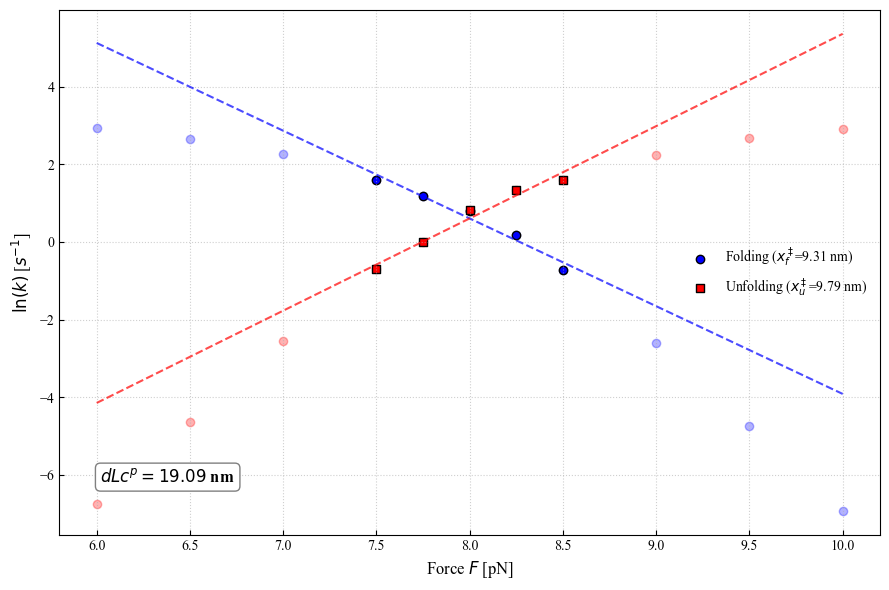

k0_f (estrapolato): 1.33e+08 s^-1
k0_u (estrapolato): 9.97e-09 s^-1


In [129]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Assicurati che kT sia definito (es. 4.114 pN*nm)
# df_fortran["F_real"] = df_fortran["F"] + 8 (se 'F' sono i delta rispetto a 8)

# 1. Filtriamo solo il range dove Bell è lineare (7.5 - 8.5)
mask = (df_fortran["F_real"] >= 7.5) & (df_fortran["F_real"] <= 8.5)
df_fit = df_fortran[mask]

# 2. Fit lineare sui dati selezionati
fold_fit = linregress(df_fit["F_real"], np.log(df_fit["folding_rate"]))
unfold_fit = linregress(df_fit["F_real"], np.log(df_fit["unfolding_rate"]))

# 3. Parametri fisici
x_dag_fold = abs(fold_fit.slope * kT)
x_dag_unfold = abs(unfold_fit.slope * kT)
dLc_p = x_dag_fold + x_dag_unfold # Come preferisci definire dLc^p

# 4. k0 corretto (usando np.exp)
k0_f = np.exp(fold_fit.intercept)
k0_u = np.exp(unfold_fit.intercept)

# ----------- PLOT PROFESSIONALE -------------
plt.figure(figsize=(9, 6))

# Punti fuori dal fit (semitrasparenti)
plt.scatter(df_fortran["F_real"], np.log(df_fortran["folding_rate"]), color='blue', alpha=0.3)
plt.scatter(df_fortran["F_real"], np.log(df_fortran["unfolding_rate"]), color='red', alpha=0.3)

# Punti usati per il fit (pieni)
plt.scatter(df_fit["F_real"], np.log(df_fit["folding_rate"]), color='blue', label=f"Folding ($x^\ddagger_f$={x_dag_fold:.2f} nm)", edgecolors='black')
plt.scatter(df_fit["F_real"], np.log(df_fit["unfolding_rate"]), color='red', label=f"Unfolding ($x^\ddagger_u$={x_dag_unfold:.2f} nm)", marker='s', edgecolors='black')

# Retta di Bell estesa
F_ext = np.linspace(6, 10, 100)
plt.plot(F_ext, fold_fit.intercept + fold_fit.slope * F_ext, 'b--', alpha=0.7)
plt.plot(F_ext, unfold_fit.intercept + unfold_fit.slope * F_ext, 'r--', alpha=0.7)

plt.xlabel("Force $F$ [pN]")
plt.ylabel(r"$\ln(k)$ [$s^{-1}$]")

# Box dLc^p spostato in un punto libero (es. in basso a sinistra)
plt.annotate(f'$dLc^p = {dLc_p:.2f}$ nm', xy=(0.05, 0.1), xycoords='axes fraction', 
             fontsize=12, fontweight='bold', bbox=dict(boxstyle="round", fc="white", ec="gray"))

plt.legend(frameon=False)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('bell_fit.pdf', format='pdf', bbox_inches='tight')

plt.show()


print(f"k0_f (estrapolato): {k0_f:.2e} s^-1")
print(f"k0_u (estrapolato): {k0_u:.2e} s^-1")

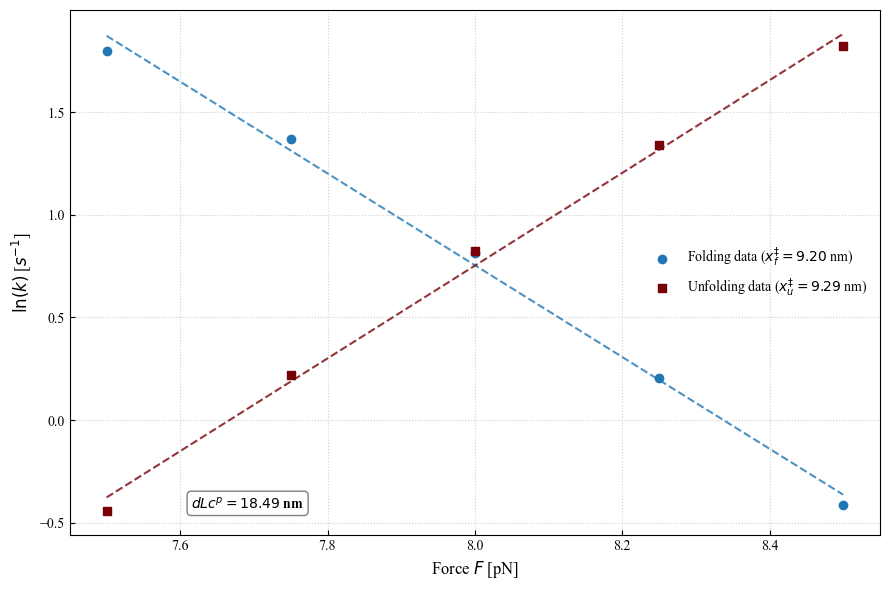

RESULTS AT F=0:
k0_folding:   1.24e+08 s^-1
k0_unfolding: 3.02e-08 s^-1
dLc^p:        18.49 nm


In [116]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Costanti fisiche
kT = 4.114  # pN * nm (a temperatura ambiente)

# Fit lineare
fold_fit = linregress(df_final["F_real"], np.log(df_final["folding_rate"]))
unfold_fit = linregress(df_final["F_real"], np.log(df_final["unfolding_rate"]))

# Estrazione parametri fisici
x_dag_fold = abs(fold_fit.slope * kT)
x_dag_unfold = abs(unfold_fit.slope * kT)
dLc_p = x_dag_fold + x_dag_unfold

# Calcolo k0 corretto (usando exp per invertire ln)
k0_f = np.exp(fold_fit.intercept)
k0_u = np.exp(unfold_fit.intercept)

# ----------- PLOT -------------
plt.figure(figsize=(9, 6))

# Dati e Fit Folding
plt.scatter(df_final["F_real"], np.log(df_final["folding_rate"]), 
            label=f"Folding data ($x^{{\ddagger}}_f = {x_dag_fold:.2f}$ nm)", color='#1f77b4', zorder=3)
plt.plot(df_final["F_real"], fold_fit.intercept + fold_fit.slope * df_final["F_real"], 
         linestyle="--", color='#1f77b4', alpha=0.8)

# Dati e Fit Unfolding
plt.scatter(df_final["F_real"], np.log(df_final["unfolding_rate"]), 
            label=f"Unfolding data ($x^{{\ddagger}}_u = {x_dag_unfold:.2f}$ nm)", color="#770309", marker='s', zorder=3)
plt.plot(df_final["F_real"], unfold_fit.intercept + unfold_fit.slope * df_final["F_real"], 
         linestyle="--", color='#770309', alpha=0.8)

# Formattazione
plt.xlabel("Force $F$ [pN]", fontsize=12)
plt.ylabel(r"$\ln(k)$ [$s^{-1}$]", fontsize=12)

# Annotation per dLc^p
plt.annotate(f'$dLc^p = {dLc_p:.2f}$ nm', xy=(0.15, 0.05), xycoords='axes fraction', 
             fontsize=10, fontweight='bold', bbox=dict(boxstyle="round", fc="white", ec="gray"))

plt.legend(frameon=False, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Salvataggio
plt.savefig('bell_fit_linear.pdf', format='pdf')
plt.show()

# Stampa risultati puliti
print(f"RESULTS AT F=0:")
print(f"k0_folding:   {k0_f:.2e} s^-1")
print(f"k0_unfolding: {k0_u:.2e} s^-1")
print(f"dLc^p:        {dLc_p:.2f} nm")